In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
import json
import os
from datetime import datetime
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import shap
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

In [48]:
df_with_selected_features_and_all_outliers = pd.read_csv("../data/data_cleaned_selected_with_all_outliers.csv", index_col=0)
df_with_selected_features_and_no_outliers = pd.read_csv("../data/data_cleaned_selected_with_no_outliers.csv", index_col=0)
df_with_all_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_all_outliers_and_all_features.csv", index_col=0)
df_with_no_outliers_and_all_features = pd.read_csv("../data/data_cleaned_with_no_outliers_and_all_features.csv", index_col=0)
print("Daa Shape of df_with_selected_features_and_all_outliers: ", df_with_selected_features_and_all_outliers.shape)
print("Daa Shape of df_with_selected_features_and_no_outliers: ", df_with_selected_features_and_no_outliers.shape)
print("Daa Shape of df_with_all_outliers_and_all_features: ", df_with_all_outliers_and_all_features.shape)
print("Daa Shape of df_with_no_outliers_and_all_features: ", df_with_no_outliers_and_all_features.shape)

Daa Shape of df_with_selected_features_and_all_outliers:  (4424, 6)
Daa Shape of df_with_selected_features_and_no_outliers:  (4335, 6)
Daa Shape of df_with_all_outliers_and_all_features:  (4424, 35)
Daa Shape of df_with_no_outliers_and_all_features:  (4335, 35)


In [49]:
X_a_o_a_f = df_with_all_outliers_and_all_features.drop("Target", axis=1)
y_a_o_a_f = df_with_all_outliers_and_all_features["Target"]
X_a_o_s_f = df_with_selected_features_and_all_outliers.drop("Target", axis=1)
y_a_o_s_f = df_with_selected_features_and_all_outliers["Target"]
X_n_o_a_f = df_with_no_outliers_and_all_features.drop("Target", axis=1)
y_n_o_a_f = df_with_no_outliers_and_all_features["Target"]
X_n_o_s_f = df_with_selected_features_and_no_outliers.drop("Target", axis=1)
y_n_o_s_f = df_with_selected_features_and_no_outliers["Target"]

X_train_a_o_a_f, X_test_a_o_a_f, y_train_a_o_a_f, y_test_a_o_a_f = train_test_split(X_a_o_a_f, y_a_o_a_f, test_size=0.2, random_state=42)
X_train_a_o_s_f, X_test_a_o_s_f, y_train_a_o_s_f, y_test_a_o_s_f = train_test_split(X_a_o_s_f, y_a_o_s_f, test_size=0.2, random_state=42)
X_train_n_o_a_f, X_test_n_o_a_f, y_train_n_o_a_f, y_test_n_o_a_f = train_test_split(X_n_o_a_f, y_n_o_a_f, test_size=0.2, random_state=42)
X_train_n_o_s_f, X_test_n_o_s_f, y_train_n_o_s_f, y_test_n_o_s_f = train_test_split(X_n_o_s_f, y_n_o_s_f, test_size=0.2, random_state=42)

In [50]:
# Random Forest Classifier without  hyperparameter tuning
rf_a_o_a_f = RandomForestClassifier(random_state=42)
rf_a_o_a_f.fit(X_train_a_o_a_f, y_train_a_o_a_f)
rf_a_o_s_f = RandomForestClassifier(random_state=42)
rf_a_o_s_f.fit(X_train_a_o_s_f, y_train_a_o_s_f)
rf_n_o_a_f = RandomForestClassifier(random_state=42)
rf_n_o_a_f.fit(X_train_n_o_a_f, y_train_n_o_a_f)
rf_n_o_s_f = RandomForestClassifier(random_state=42)
rf_n_o_s_f.fit(X_train_n_o_s_f, y_train_n_o_s_f)

rf_a_o_a_f_pred = rf_a_o_a_f.predict(X_test_a_o_a_f)
rf_a_o_s_f_pred = rf_a_o_s_f.predict(X_test_a_o_s_f)
rf_n_o_a_f_pred = rf_n_o_a_f.predict(X_test_n_o_a_f)
rf_n_o_s_f_pred = rf_n_o_s_f.predict(X_test_n_o_s_f)

# Classification Report
print("Classification Report - Random Forest Classifier with All Outliers and All Features:")
print(classification_report(y_test_a_o_a_f, rf_a_o_a_f_pred))
print("Classification Report - Random Forest Classifier with All Outliers and Selected Features:")
print(classification_report(y_test_a_o_s_f, rf_a_o_s_f_pred))

Classification Report - Random Forest Classifier with All Outliers and All Features:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       316
           1       0.53      0.32      0.40       151
           2       0.78      0.94      0.85       418

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.68       885
weighted avg       0.76      0.77      0.76       885

Classification Report - Random Forest Classifier with All Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74       316
           1       0.36      0.30      0.33       151
           2       0.76      0.83      0.80       418

    accuracy                           0.70       885
   macro avg       0.63      0.62      0.62       885
weighted avg       0.69      0.70      0.70       885



In [51]:
print("Classification Report - Random Forest Classifier with No Outliers and All Features:")
print(classification_report(y_test_n_o_a_f, rf_n_o_a_f_pred))
print("Classification Report - Random Forest Classifier with No Outliers and Selected Features:")
print(classification_report(y_test_n_o_s_f, rf_n_o_s_f_pred))

Classification Report - Random Forest Classifier with No Outliers and All Features:
              precision    recall  f1-score   support

           0       0.76      0.73      0.75       256
           1       0.56      0.41      0.47       169
           2       0.81      0.92      0.86       442

    accuracy                           0.76       867
   macro avg       0.71      0.69      0.69       867
weighted avg       0.75      0.76      0.75       867

Classification Report - Random Forest Classifier with No Outliers and Selected Features:
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       256
           1       0.42      0.31      0.36       169
           2       0.79      0.82      0.81       442

    accuracy                           0.71       867
   macro avg       0.64      0.63      0.63       867
weighted avg       0.69      0.71      0.70       867



Confusion Matrix - Random Forest Classifier with All Outliers and All Features:


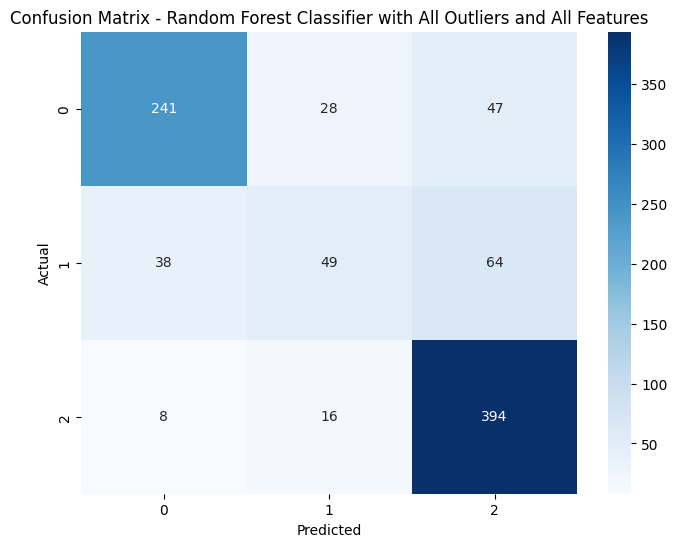

Confusion Matrix - Random Forest Classifier with All Outliers and Selected Features:
[[227  43  46]
 [ 43  46  62]
 [ 30  39 349]]


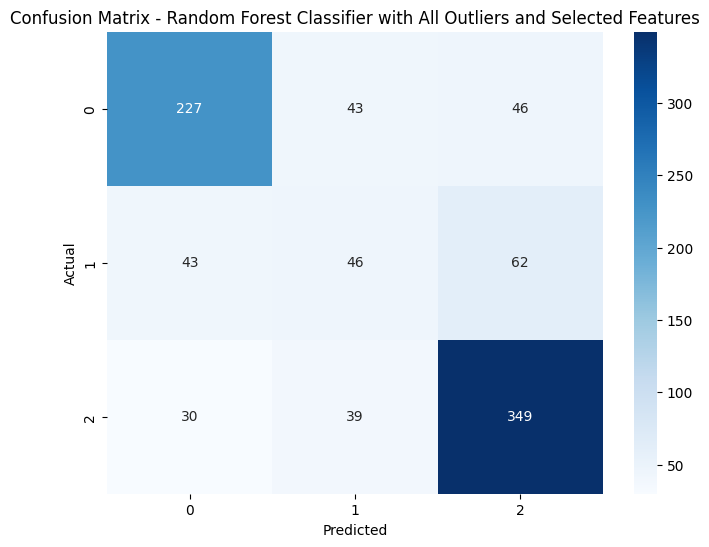

Confusion Matrix - Random Forest Classifier with No Outliers and All Features:
[[188  34  34]
 [ 42  69  58]
 [ 17  20 405]]


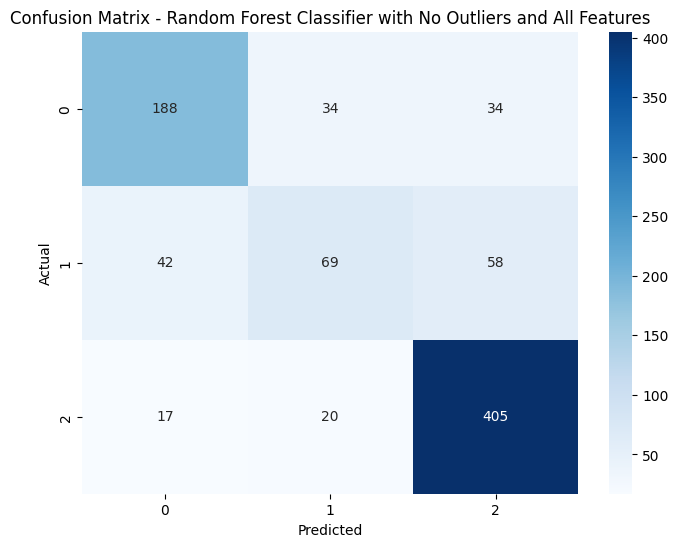

Confusion Matrix - Random Forest Classifier with No Outliers and Selected Features:
[[197  30  29]
 [ 49  53  67]
 [ 37  42 363]]


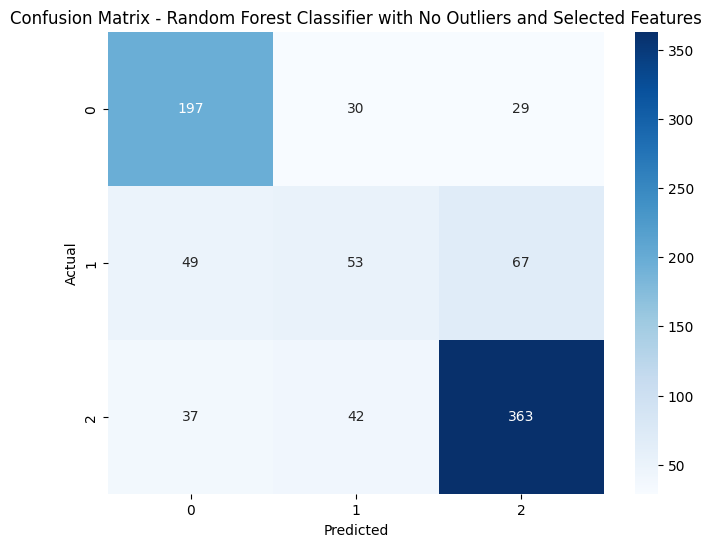

In [52]:
# Plot Confusion Matrix Chart
print("Confusion Matrix - Random Forest Classifier with All Outliers and All Features:")
confusion_matrix(y_test_a_o_a_f, rf_a_o_a_f_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_a_f, rf_a_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest Classifier with All Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Random Forest Classifier with All Outliers and Selected Features:")
print(confusion_matrix(y_test_a_o_s_f, rf_a_o_s_f_pred))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_a_o_s_f, rf_a_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest Classifier with All Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Random Forest Classifier with No Outliers and All Features:")
print(confusion_matrix(y_test_n_o_a_f, rf_n_o_a_f_pred))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_a_f, rf_n_o_a_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest Classifier with No Outliers and All Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Confusion Matrix - Random Forest Classifier with No Outliers and Selected Features:")
print(confusion_matrix(y_test_n_o_s_f, rf_n_o_s_f_pred))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_n_o_s_f, rf_n_o_s_f_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest Classifier with No Outliers and Selected Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
# Accuracy Score
print("Accuracy Score - Random Forest Classifier with All Outliers and All Features:", accuracy_score(y_test_a_o_a_f, rf_a_o_a_f_pred))
print("Accuracy Score - Random Forest Classifier with All Outliers and Selected Features:", accuracy_score(y_test_a_o_s_f, rf_a_o_s_f_pred))
print("Accuracy Score - Random Forest Classifier with No Outliers and All Features:", accuracy_score(y_test_n_o_a_f, rf_n_o_a_f_pred))
print("Accuracy Score - Random Forest Classifier with No Outliers and Selected Features:", accuracy_score(y_test_n_o_s_f, rf_n_o_s_f_pred))

Accuracy Score - Random Forest Classifier with All Outliers and All Features: 0.7728813559322034
Accuracy Score - Random Forest Classifier with All Outliers and Selected Features: 0.7028248587570621
Accuracy Score - Random Forest Classifier with No Outliers and All Features: 0.7635524798154556
Accuracy Score - Random Forest Classifier with No Outliers and Selected Features: 0.707035755478662


In [54]:
# ROC AUC Score
print("ROC AUC Score - Random Forest Classifier with All Outliers and All Features:", roc_auc_score(y_test_a_o_a_f, rf_a_o_a_f.predict_proba(X_test_a_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Random Forest Classifier with All Outliers and Selected Features:", roc_auc_score(y_test_a_o_s_f, rf_a_o_s_f.predict_proba(X_test_a_o_s_f), multi_class='ovr'))
print("ROC AUC Score - Random Forest Classifier with No Outliers and All Features:", roc_auc_score(y_test_n_o_a_f, rf_n_o_a_f.predict_proba(X_test_n_o_a_f), multi_class='ovr'))
print("ROC AUC Score - Random Forest Classifier with No Outliers and Selected Features:", roc_auc_score(y_test_n_o_s_f, rf_n_o_s_f.predict_proba(X_test_n_o_s_f), multi_class='ovr'))

ROC AUC Score - Random Forest Classifier with All Outliers and All Features: 0.8726767103042349
ROC AUC Score - Random Forest Classifier with All Outliers and Selected Features: 0.8122475651181856
ROC AUC Score - Random Forest Classifier with No Outliers and All Features: 0.8941158015477159
ROC AUC Score - Random Forest Classifier with No Outliers and Selected Features: 0.8303005875547377


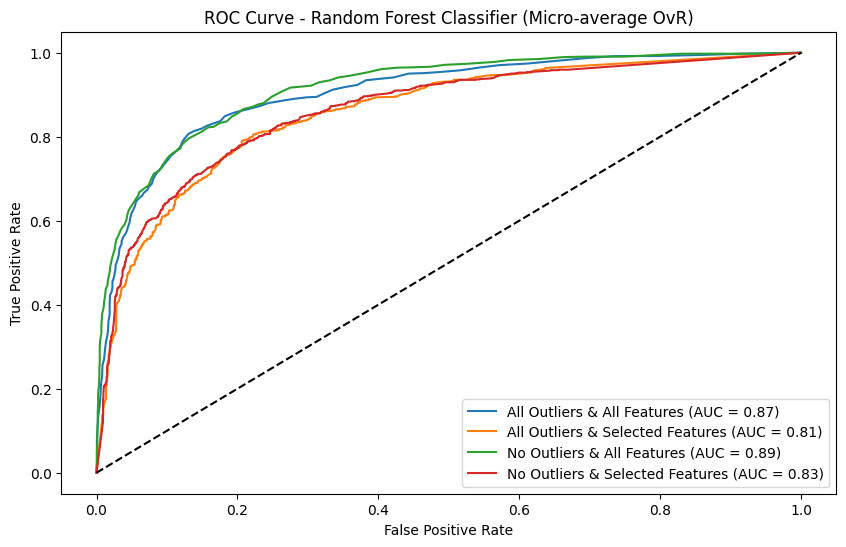

In [55]:
# ROC Curve (multiclass-safe, micro-average)
def get_micro_roc(y_true, y_proba, class_labels):
    y_true_bin = label_binarize(y_true, classes=class_labels)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    auc_score = roc_auc_score(y_true, y_proba, multi_class='ovr')
    return fpr, tpr, auc_score

fpr_a_o_a_f, tpr_a_o_a_f, auc_a_o_a_f = get_micro_roc(
    y_test_a_o_a_f, rf_a_o_a_f.predict_proba(X_test_a_o_a_f), rf_a_o_a_f.classes_
)
fpr_a_o_s_f, tpr_a_o_s_f, auc_a_o_s_f = get_micro_roc(
    y_test_a_o_s_f, rf_a_o_s_f.predict_proba(X_test_a_o_s_f), rf_a_o_s_f.classes_
)
fpr_n_o_a_f, tpr_n_o_a_f, auc_n_o_a_f = get_micro_roc(
    y_test_n_o_a_f, rf_n_o_a_f.predict_proba(X_test_n_o_a_f), rf_n_o_a_f.classes_
)
fpr_n_o_s_f, tpr_n_o_s_f, auc_n_o_s_f = get_micro_roc(
    y_test_n_o_s_f, rf_n_o_s_f.predict_proba(X_test_n_o_s_f), rf_n_o_s_f.classes_
)

plt.figure(figsize=(10, 6))
plt.plot(fpr_a_o_a_f, tpr_a_o_a_f, label='All Outliers & All Features (AUC = {:.2f})'.format(auc_a_o_a_f))
plt.plot(fpr_a_o_s_f, tpr_a_o_s_f, label='All Outliers & Selected Features (AUC = {:.2f})'.format(auc_a_o_s_f))
plt.plot(fpr_n_o_a_f, tpr_n_o_a_f, label='No Outliers & All Features (AUC = {:.2f})'.format(auc_n_o_a_f))
plt.plot(fpr_n_o_s_f, tpr_n_o_s_f, label='No Outliers & Selected Features (AUC = {:.2f})'.format(auc_n_o_s_f))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Classifier (Micro-average OvR)')
plt.legend(loc='lower right')
plt.show()